In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re
import requests
from bs4 import BeautifulSoup
from urllib.request import urlopen
import os
import time
from unidecode import unidecode
import warnings
from mplsoccer.pitch import Pitch
import seaborn as sns
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [31]:
match_html_path = r"C:\Users\K Raghunandan\Analyst\Matches\Manchester United 2-1 Crystal Palace - Premier League 2025_2026 Live.html"
fotmob_matchId = 4813652

def extract_json_from_html(html_path, save_output=False):
    with open(html_path, 'r', encoding='utf-8') as html_file:
        html = html_file.read()

    regex_pattern = r'(?<=require\.config\.params\["args"\].=.)[\s\S]*?;'
    data_txt = re.findall(regex_pattern, html)[0]

    # add quotations for JSON parser
    data_txt = data_txt.replace('matchId', '"matchId"')
    data_txt = data_txt.replace('matchCentreData', '"matchCentreData"')
    data_txt = data_txt.replace('matchCentreEventTypeJson', '"matchCentreEventTypeJson"')
    data_txt = data_txt.replace('formationIdNameMappings', '"formationIdNameMappings"')
    data_txt = data_txt.replace('};', '}')

    if save_output:
        # save JSON data to txt
        output_file = open(f"{html_path}.txt", "wt", encoding='utf-8')
        n = output_file.write(data_txt)
        output_file.close()

    return data_txt

def extract_data_from_dict(data):
    # load data from json
    event_types_json = data["matchCentreEventTypeJson"]
    formation_mappings = data["formationIdNameMappings"]
    events_dict = data["matchCentreData"]["events"]
    teams_dict = {data["matchCentreData"]['home']['teamId']: data["matchCentreData"]['home']['name'],
                  data["matchCentreData"]['away']['teamId']: data["matchCentreData"]['away']['name']}
    players_dict = data["matchCentreData"]["playerIdNameDictionary"]
    # create players dataframe
    players_home_df = pd.DataFrame(data["matchCentreData"]['home']['players'])
    players_home_df["teamId"] = data["matchCentreData"]['home']['teamId']
    players_away_df = pd.DataFrame(data["matchCentreData"]['away']['players'])
    players_away_df["teamId"] = data["matchCentreData"]['away']['teamId']
    players_df = pd.concat([players_home_df, players_away_df])
    players_ids = data["matchCentreData"]["playerIdNameDictionary"]
    return events_dict, players_df, teams_dict

def get_short_name(full_name):
    if pd.isna(full_name):
        return full_name
    parts = full_name.split()
    if len(parts) == 1:
        return full_name  # No need for short name if there's only one word
    elif len(parts) == 2:
        return parts[0][0] + ". " + parts[1]
    else:
        return parts[0][0] + ". " + parts[1][0] + ". " + " ".join(parts[2:])

json_data_txt = extract_json_from_html(match_html_path)
data = json.loads(json_data_txt)
events_dict, players_df, teams_dict = extract_data_from_dict(data)

df = pd.DataFrame(events_dict)
dfp = pd.DataFrame(players_df)
dfp['shortName'] = dfp['name'].apply(get_short_name)

In [32]:
df['type'] = df['type'].str.extract(r"'displayName': '([^']+)")
df['outcomeType'] = df['outcomeType'].str.extract(r"'displayName': '([^']+)")
df['period'] = df['period'].str.extract(r"'displayName': '([^']+)")

In [33]:
df['teamName'] = df['teamId'].map(teams_dict)
team_names = list(teams_dict.values())
opposition_dict = {team_names[i]: team_names[1-i] for i in range(len(team_names))}
df['oppositionTeamName'] = df['teamName'].map(opposition_dict)

In [34]:
df['x'] = df['x']*1.2
df['y'] = df['y']*0.8
df['endX'] = df['endX']*1.2
df['endY'] = df['endY']*0.8
df['goalMouthY'] = df['goalMouthY']*0.8

In [35]:
columns_to_drop = ['height', 'weight', 'age', 'isManOfTheMatch', 'field', 'stats', 
                   'subbedInPlayerId', 'subbedOutPeriod', 
                   'subbedOutExpandedMinute', 'subbedInPeriod', 'subbedInExpandedMinute', 'subbedOutPlayerId', 
                   'teamId']
dfp.drop(columns=columns_to_drop, inplace=True)

In [36]:
df = df.merge(dfp, on='playerId', how='left')

In [37]:
df

,id,eventId,minute,second,teamId,x,y,expandedMinute,period,type,...,blockedY,isGoal,cardType,teamName,oppositionTeamName,shirtNo,name,position,isFirstEleven,shortName
0,2.906053e+09,3,0,0.0,32,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,Man Utd,Crystal Palace,NaN,NaN,NaN,NaN,NaN
1,2.906053e+09,3,0,0.0,162,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,Crystal Palace,Man Utd,NaN,NaN,NaN,NaN,NaN
2,2.906053e+09,4,0,0.0,32,59.88,40.08,0,NaN,NaN,...,NaN,NaN,NaN,Man Utd,Crystal Palace,8.0,Bruno Fernandes,AMC,True,B. Fernandes
3,2.906053e+09,5,0,4.0,32,33.12,41.04,0,NaN,NaN,...,NaN,NaN,NaN,Man Utd,Crystal Palace,31.0,Senne Lammens,GK,True,S. Lammens
4,2.906053e+09,4,0,7.0,162,25.32,58.40,0,NaN,NaN,...,NaN,NaN,NaN,Crystal Palace,Man Utd,5.0,Maxence Lacroix,DC,True,M. Lacroix
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1612,2.906149e+09,965,98,23.0,32,0.00,0.00,102,NaN,NaN,...,NaN,NaN,NaN,Man Utd,Crystal Palace,NaN,NaN,NaN,NaN,NaN
1613,2.906149e+09,765,0,0.0,162,0.00,0.00,12,NaN,NaN,...,NaN,NaN,NaN,Crystal Palace,Man Utd,NaN,NaN,NaN,NaN,NaN
1614,2.906149e+09,966,0,0.0,32,0.00,0.00,12,NaN,NaN,...,NaN,NaN,NaN,Man Utd,Crystal Palace,NaN,NaN,NaN,NaN,NaN
1615,2.906015e+09,2,0,0.0,32,0.00,0.00,0,NaN,NaN,...,NaN,NaN,NaN,Man Utd,Crystal Palace,NaN,NaN,NaN,NaN,NaN


In [38]:
dfp

,playerId,shirtNo,name,position,isFirstEleven,shortName
0,402184,31,Senne Lammens,GK,True,S. Lammens
1,353418,2,Diogo Dalot,DR,True,D. Dalot
2,437299,15,Leny Yoro,DC,True,L. Yoro
3,99487,5,Harry Maguire,DC,True,H. Maguire
4,118244,23,Luke Shaw,DL,True,L. Shaw
5,88526,18,Casemiro,DMC,True,Casemiro
6,460260,37,Kobbie Mainoo,DMC,True,K. Mainoo
7,353377,19,Bryan Mbeumo,AMR,True,B. Mbeumo
8,123761,8,Bruno Fernandes,AMC,True,B. Fernandes
9,362758,10,Matheus Cunha,AML,True,M. Cunha


In [39]:
df = df[
    ((df['x'].notna()) & 
    (df['y'].notna()) & 
    (df['endX'].notna()) & 
    (df['endY'].notna())) | 
    ((df['x'].notna()) & 
    (df['y'].notna()) & 
    (df['goalMouthY'].notna()))
]

In [40]:
df=df.reset_index()

In [41]:
df

,index,id,eventId,minute,second,teamId,x,y,expandedMinute,period,...,blockedY,isGoal,cardType,teamName,oppositionTeamName,shirtNo,name,position,isFirstEleven,shortName
0,2,2.906053e+09,4,0,0.0,32,59.88,40.08,0,NaN,...,NaN,NaN,NaN,Man Utd,Crystal Palace,8.0,Bruno Fernandes,AMC,True,B. Fernandes
1,3,2.906053e+09,5,0,4.0,32,33.12,41.04,0,NaN,...,NaN,NaN,NaN,Man Utd,Crystal Palace,31.0,Senne Lammens,GK,True,S. Lammens
2,4,2.906053e+09,4,0,7.0,162,25.32,58.40,0,NaN,...,NaN,NaN,NaN,Crystal Palace,Man Utd,5.0,Maxence Lacroix,DC,True,M. Lacroix
3,6,2.906053e+09,6,0,10.0,162,30.60,77.04,0,NaN,...,NaN,NaN,NaN,Crystal Palace,Man Utd,3.0,Tyrick Mitchell,DML,True,T. Mitchell
4,9,2.906053e+09,7,0,14.0,162,44.88,71.12,0,NaN,...,NaN,NaN,NaN,Crystal Palace,Man Utd,18.0,Daichi Kamada,MC,True,D. Kamada
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1142,1601,2.906148e+09,962,98,2.0,32,78.36,62.24,102,NaN,...,NaN,NaN,NaN,Man Utd,Crystal Palace,11.0,Joshua Zirkzee,Sub,NaN,J. Zirkzee
1143,1604,2.906148e+09,759,98,6.0,162,41.52,25.04,102,NaN,...,NaN,NaN,NaN,Crystal Palace,Man Utd,19.0,Will Hughes,Sub,NaN,W. Hughes
1144,1607,2.906149e+09,761,98,16.0,162,73.68,78.72,102,NaN,...,NaN,NaN,NaN,Crystal Palace,Man Utd,3.0,Tyrick Mitchell,DML,True,T. Mitchell
1145,1608,2.906149e+09,762,98,19.0,162,85.44,54.96,102,NaN,...,NaN,NaN,NaN,Crystal Palace,Man Utd,10.0,Yéremy Pino,Sub,NaN,Y. Pino


In [42]:
df=df[["minute","second","x","y","endX","endY","teamName","shirtNo","position","shortName","goalMouthY","isShot","isGoal"]]

In [43]:
df

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal
0,0,0.0,59.88,40.08,32.88,40.08,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN
1,0,4.0,33.12,41.04,91.56,22.64,Man Utd,31.0,GK,S. Lammens,NaN,NaN,NaN
2,0,7.0,25.32,58.40,30.60,76.56,Crystal Palace,5.0,DC,M. Lacroix,NaN,NaN,NaN
3,0,10.0,30.60,77.04,61.56,69.84,Crystal Palace,3.0,DML,T. Mitchell,NaN,NaN,NaN
4,0,14.0,44.88,71.12,47.40,70.40,Crystal Palace,18.0,MC,D. Kamada,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1142,98,2.0,78.36,62.24,85.20,58.88,Man Utd,11.0,Sub,J. Zirkzee,NaN,NaN,NaN
1143,98,6.0,41.52,25.04,57.96,26.16,Crystal Palace,19.0,Sub,W. Hughes,NaN,NaN,NaN
1144,98,16.0,73.68,78.72,83.76,59.76,Crystal Palace,3.0,DML,T. Mitchell,NaN,NaN,NaN
1145,98,19.0,85.44,54.96,102.60,35.60,Crystal Palace,10.0,Sub,Y. Pino,NaN,NaN,NaN


In [62]:
df_xT.to_csv('players.csv', index=False)

In [45]:
xT=pd.read_csv("C:/Users/K Raghunandan/OneDrive/Desktop/Raghu/Kickoff/CSV Files/xT_Grid.csv",header = None)
xT.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.006383,0.007796,0.008449,0.009777,0.011263,0.012483,0.014736,0.017451,0.021221,0.027563,0.034851,0.037926
1,0.007501,0.008786,0.009424,0.010595,0.012147,0.013845,0.016118,0.018703,0.024015,0.029533,0.040670,0.046477
2,0.008880,0.009777,0.010013,0.011105,0.012692,0.014291,0.016856,0.019351,0.024122,0.028552,0.054911,0.064426
3,0.009411,0.010827,0.010165,0.011324,0.012626,0.014846,0.016895,0.019971,0.023851,0.035113,0.108051,0.257454
4,0.009411,0.010827,0.010165,0.011324,0.012626,0.014846,0.016895,0.019971,0.023851,0.035113,0.108051,0.257454


In [46]:
xT=np.array(xT)
xT

array([[0.00638303, 0.00779616, 0.00844854, 0.00977659, 0.01126267,
        0.01248344, 0.01473596, 0.0174506 , 0.02122129, 0.02756312,
        0.03485072, 0.0379259 ],
       [0.00750072, 0.00878589, 0.00942382, 0.0105949 , 0.01214719,
        0.0138454 , 0.01611813, 0.01870347, 0.02401521, 0.02953272,
        0.04066992, 0.04647721],
       [0.0088799 , 0.00977745, 0.01001304, 0.01110462, 0.01269174,
        0.01429128, 0.01685596, 0.01935132, 0.0241224 , 0.02855202,
        0.05491138, 0.06442595],
       [0.00941056, 0.01082722, 0.01016549, 0.01132376, 0.01262646,
        0.01484598, 0.01689528, 0.0199707 , 0.02385149, 0.03511326,
        0.10805102, 0.25745362],
       [0.00941056, 0.01082722, 0.01016549, 0.01132376, 0.01262646,
        0.01484598, 0.01689528, 0.0199707 , 0.02385149, 0.03511326,
        0.10805102, 0.25745362],
       [0.0088799 , 0.00977745, 0.01001304, 0.01110462, 0.01269174,
        0.01429128, 0.01685596, 0.01935132, 0.0241224 , 0.02855202,
        0.05491138,

In [47]:
xT_rows, xT_cols = xT.shape

In [48]:
xT_rows

8

In [49]:
xT_cols

12

In [50]:
df["x1_bin"]=pd.cut(df["x"],bins=xT_cols,labels=False)
df["y1_bin"]=pd.cut(df["y"],bins=xT_rows,labels=False)
df["x2_bin"]=pd.cut(df["endX"],bins=xT_cols,labels=False)
df["y2_bin"]=pd.cut(df["endY"],bins=xT_rows,labels=False)

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_24388\2369042483.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["x1_bin"]=pd.cut(df["x"],bins=xT_cols,labels=False)
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_24388\2369042483.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["y1_bin"]=pd.cut(df["y"],bins=xT_rows,labels=False)
C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_24388\2369042483.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

In [51]:
df

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal,x1_bin,y1_bin,x2_bin,y2_bin
0,0,0.0,59.88,40.08,32.88,40.08,Man Utd,8.0,AMC,B. Fernandes,NaN,NaN,NaN,6,4,3.0,4.0
1,0,4.0,33.12,41.04,91.56,22.64,Man Utd,31.0,GK,S. Lammens,NaN,NaN,NaN,3,4,9.0,2.0
2,0,7.0,25.32,58.40,30.60,76.56,Crystal Palace,5.0,DC,M. Lacroix,NaN,NaN,NaN,2,5,3.0,7.0
3,0,10.0,30.60,77.04,61.56,69.84,Crystal Palace,3.0,DML,T. Mitchell,NaN,NaN,NaN,3,7,6.0,6.0
4,0,14.0,44.88,71.12,47.40,70.40,Crystal Palace,18.0,MC,D. Kamada,NaN,NaN,NaN,4,7,4.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1142,98,2.0,78.36,62.24,85.20,58.88,Man Utd,11.0,Sub,J. Zirkzee,NaN,NaN,NaN,7,6,8.0,5.0
1143,98,6.0,41.52,25.04,57.96,26.16,Crystal Palace,19.0,Sub,W. Hughes,NaN,NaN,NaN,4,2,5.0,2.0
1144,98,16.0,73.68,78.72,83.76,59.76,Crystal Palace,3.0,DML,T. Mitchell,NaN,NaN,NaN,7,7,8.0,5.0
1145,98,19.0,85.44,54.96,102.60,35.60,Crystal Palace,10.0,Sub,Y. Pino,NaN,NaN,NaN,8,5,10.0,3.0


In [54]:
df=df.fillna(value=0)

In [55]:
df["start_zone_value"] = xT[
    df["y1_bin"].astype(int),
    df["x1_bin"].astype(int)
]

df["end_zone_value"] = xT[
    df["y2_bin"].astype(int),
    df["x2_bin"].astype(int)
]

In [56]:
df

,minute,second,x,y,endX,endY,teamName,shirtNo,position,shortName,goalMouthY,isShot,isGoal,x1_bin,y1_bin,x2_bin,y2_bin,start_zone_value,end_zone_value
0,0,0.0,59.88,40.08,32.88,40.08,Man Utd,8.0,AMC,B. Fernandes,0.0,0,0,6,4,3.0,4.0,0.016895,0.011324
1,0,4.0,33.12,41.04,91.56,22.64,Man Utd,31.0,GK,S. Lammens,0.0,0,0,3,4,9.0,2.0,0.011324,0.028552
2,0,7.0,25.32,58.40,30.60,76.56,Crystal Palace,5.0,DC,M. Lacroix,0.0,0,0,2,5,3.0,7.0,0.010013,0.009777
3,0,10.0,30.60,77.04,61.56,69.84,Crystal Palace,3.0,DML,T. Mitchell,0.0,0,0,3,7,6.0,6.0,0.009777,0.016118
4,0,14.0,44.88,71.12,47.40,70.40,Crystal Palace,18.0,MC,D. Kamada,0.0,0,0,4,7,4.0,7.0,0.011263,0.011263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1142,98,2.0,78.36,62.24,85.20,58.88,Man Utd,11.0,Sub,J. Zirkzee,0.0,0,0,7,6,8.0,5.0,0.018703,0.024122
1143,98,6.0,41.52,25.04,57.96,26.16,Crystal Palace,19.0,Sub,W. Hughes,0.0,0,0,4,2,5.0,2.0,0.012692,0.014291
1144,98,16.0,73.68,78.72,83.76,59.76,Crystal Palace,3.0,DML,T. Mitchell,0.0,0,0,7,7,8.0,5.0,0.017451,0.024122
1145,98,19.0,85.44,54.96,102.60,35.60,Crystal Palace,10.0,Sub,Y. Pino,0.0,0,0,8,5,10.0,3.0,0.024122,0.108051


In [57]:
df["xT"]=df["end_zone_value"]-df["start_zone_value"]

In [60]:
df_xT = (
    df.groupby(["shortName", "teamName"])["xT"]
    .sum()
    .reset_index()
    .sort_values(by="xT", ascending=False)
)

In [61]:
df_xT

,shortName,teamName,xT
3,B. Fernandes,Man Utd,1.541964
5,B. Mbeumo,Man Utd,1.335029
23,M. Cunha,Man Utd,0.379648
10,D. Dalot,Man Utd,0.362603
20,K. Mainoo,Man Utd,0.344624
17,J. Canvot,Crystal Palace,0.300545
11,D. Henderson,Crystal Palace,0.293378
27,T. Mitchell,Crystal Palace,0.221161
4,B. Johnson,Crystal Palace,0.213772
29,Y. Pino,Crystal Palace,0.206534


In [67]:
df_xT = (
    df_xT
    .sort_values("xT", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

In [80]:
for x in range(len(df_xT)):
    if df_xT["teamName"][x]=="Man Utd":
        df_xT["path"][x]="C:/Users/K Raghunandan/Analyst/Logos/Premier League/Manchester United.png"
    if df_xT["teamName"][x]=="Crystal Palace":
        df_xT["path"][x]="C:/Users/K Raghunandan/Analyst/Logos/Premier League/Crystal Palace.png"

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_24388\3478251974.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_xT["path"][x]="C:/Users/K Raghunandan/Analyst/Logos/Premier League/Manchester United.png"
C:\Users\K Raghunandan\AppD

In [81]:
df_xT

,shortName,teamName,xT,path
0,B. Fernandes,Man Utd,1.541964,C:/Users/K Raghunandan/Analyst/Logos/Premier L...
1,B. Mbeumo,Man Utd,1.335029,C:/Users/K Raghunandan/Analyst/Logos/Premier L...
2,M. Cunha,Man Utd,0.379648,C:/Users/K Raghunandan/Analyst/Logos/Premier L...
3,D. Dalot,Man Utd,0.362603,C:/Users/K Raghunandan/Analyst/Logos/Premier L...
4,K. Mainoo,Man Utd,0.344624,C:/Users/K Raghunandan/Analyst/Logos/Premier L...
5,J. Canvot,Crystal Palace,0.300545,C:/Users/K Raghunandan/Analyst/Logos/Premier L...
6,D. Henderson,Crystal Palace,0.293378,C:/Users/K Raghunandan/Analyst/Logos/Premier L...
7,T. Mitchell,Crystal Palace,0.221161,C:/Users/K Raghunandan/Analyst/Logos/Premier L...
8,B. Johnson,Crystal Palace,0.213772,C:/Users/K Raghunandan/Analyst/Logos/Premier L...
9,Y. Pino,Crystal Palace,0.206534,C:/Users/K Raghunandan/Analyst/Logos/Premier L...


findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

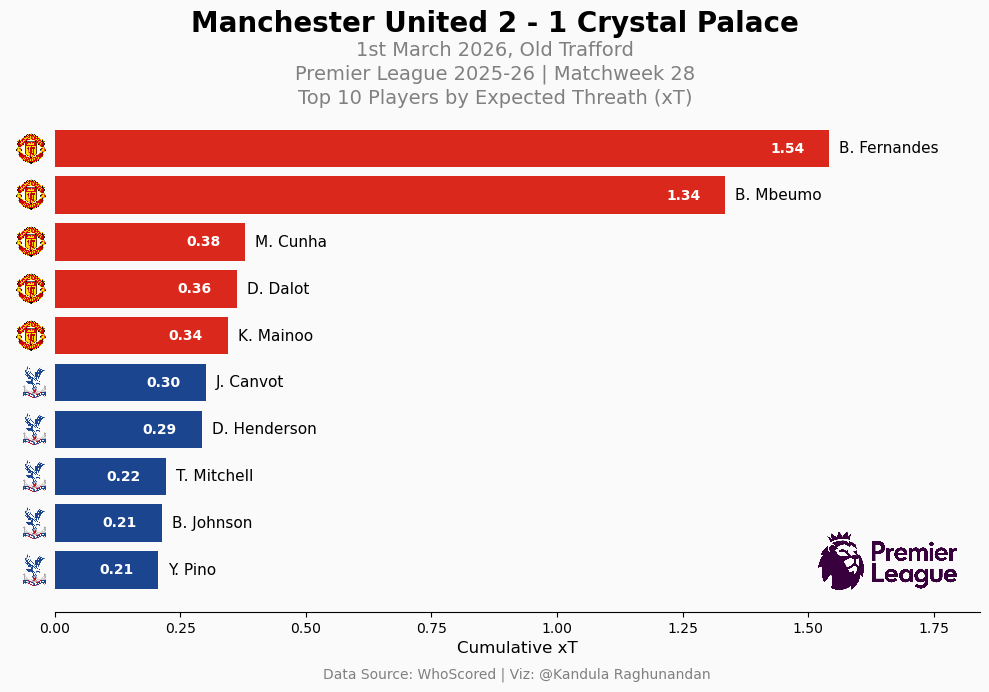

In [126]:
plt.rcParams.update({'font.family':'Avenir'})
bgcol = '#fafafa'

fig, ax = plt.subplots(figsize=(10, 6))
fig.set_facecolor(bgcol)
ax.set_facecolor(bgcol)

team_colors = {
    "Man Utd": "#DA291C",
    "Crystal Palace": "#1B458F"
}

bar_colors = df_xT["teamName"].map(team_colors)

bars = ax.barh(
    range(len(df_xT)),
    df_xT["xT"],
    color=bar_colors
)

ax.invert_yaxis()

ax.set_yticks([])

ax.set_xlabel("Cumulative xT", fontsize=12)

ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)

for i, value in enumerate(df_xT["xT"]):
    ax.text(
        value + 0.02,
        i,
        df_xT["shortName"].iloc[i],
        va="center",
        fontsize=11
    )

for i, value in enumerate(df_xT["xT"]):
    ax.text(
        value - 0.05,             
        i,
        f"{value:.2f}",             
        va="center",
        ha="right",
        fontsize=10,
        color="white",
        weight="bold"
    )

for i, team in enumerate(df_xT["teamName"]):
    try:
        logo = mpimg.imread(df_xT["path"][i])
        imagebox = OffsetImage(logo, zoom=0.06)
        ab = AnnotationBbox(
            imagebox,
            (0, i),
            frameon=False,
            box_alignment=(1.3, 0.5)
        )
        ax.add_artist(ab)
    except FileNotFoundError:
        print(f"Logo not found for {team}")

ax.set_xlim(0, df_xT["xT"].max() + 0.3)

fig.text(0.5, 1.1,
         "Manchester United 2 - 1 Crystal Palace",
         ha="center",
         fontsize=20,
         fontweight="bold")

fig.text(0.5, 1.06,
         "1st March 2026, Old Trafford",
         ha="center",
         fontsize=14,
         color="grey")

fig.text(0.5, 1.02,
         "Premier League 2025-26 | Matchweek 28",
         ha="center",
         fontsize=14,
         color="grey")

fig.text(0.5, 0.98,
         "Top 10 Players by Expected Threath (xT)",
         ha="center",
         fontsize=14,
         color="grey")

home_logo = mpimg.imread("C:/Users/K Raghunandan/Analyst/Logos/Premier League/Manchester United.png")
away_logo = mpimg.imread("C:/Users/K Raghunandan/Analyst/Logos/Premier League/Crystal Palace.png")
league_logo=mpimg.imread("C:/Users/K Raghunandan/Analyst/Logos/Premier League/PREM LOGO (2).png")

def add_logo(ax, img, zoom, xy):
    imagebox = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(imagebox, xy, frameon=False, xycoords='axes fraction')
    ax.add_artist(ab)

#add_logo(ax, home_logo, zoom=0.18, xy=(0.05, 1))
#add_logo(ax, away_logo, zoom=0.18, xy=(0.95, 1.2))
add_logo(ax, league_logo, zoom=0.05, xy=(0.9, 0.1))

plt.text(
    0.5, -0.125, "Data Source: WhoScored | Viz: @Kandula Raghunandan",
    ha="center", va="center",
    transform=plt.gca().transAxes,
    fontsize=10, color="gray"
)

plt.tight_layout()

plt.savefig(r"C:\Users\K Raghunandan\Analyst\Matches\Manchester United 2-1 Crystal Palace - Premier League 2025_2026 Live_files\New folder\xT.png",bbox_inches='tight')
plt.show()
